# How to Identify PDEs

This notebook describes the API for learning PDEs.
There are several approaches for dealing with PDEs in PySINDy:

* Using `PDELibrary` inside a `SINDy` model
* Using `PDELibrary` inside a `WeakSINDy` model
* Reduced-order modeling to convert the ODE to a PDE (potentially using `TrappingSR3`)

We'll demonstrate how to implement these approaches using two systems:
1. The 1D Burgers equation
2. The 2D compressible isothermal flow equations

In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np

# Some shortcuts to speed up runtime in CI/debugging
if __name__ == "testing":
    import mock_data as data
    import matplotlib

    matplotlib.use("Agg")
    max_iter = 10

else:
    import example_data as data

    max_iter = 1000

from utils import excess_information_loss
from utils import plot_burgers_data_and_derivative
from utils import plot_compressible_data_and_derivative
from utils import plot_field_prediction
from utils import plot_svd_energy
from utils import print_trapping_diagnostics
from utils import burgers_true_coefficients
from utils import compressible_true_coefficients

import pysindy as ps
import sindy_exp

/home/jake/github/sys_id/env13/lib/python3.13/site-packages/dysts/base.py:22: UserWarning: Numba not installed. Falling back to no JIT compilation.
  warnings.warn("Numba not installed. Falling back to no JIT compilation.")


## The data

### Burgers equation

The burger's equation is a simple PDE (here simulated on a 1-D grid)
of advection and diffusion:

$$u_t = -u u_x + \nu u_{xx}$$

Burgers 99% energy rank: 4
Burgers number of SVD modes 4


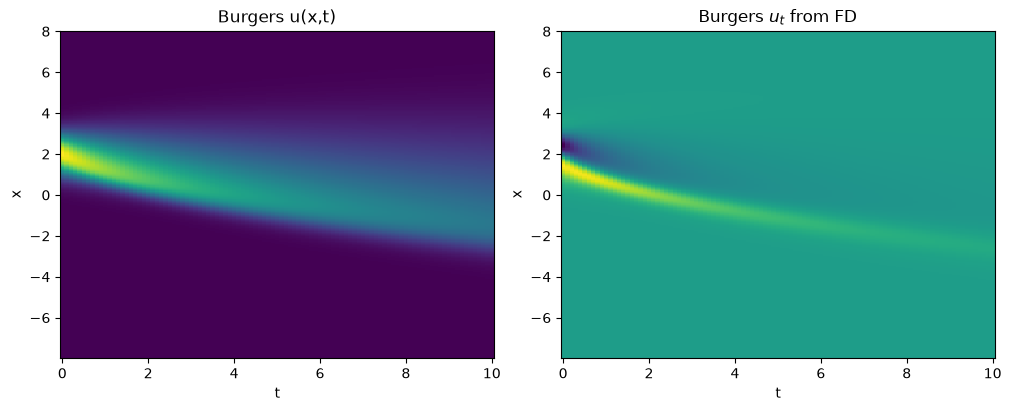

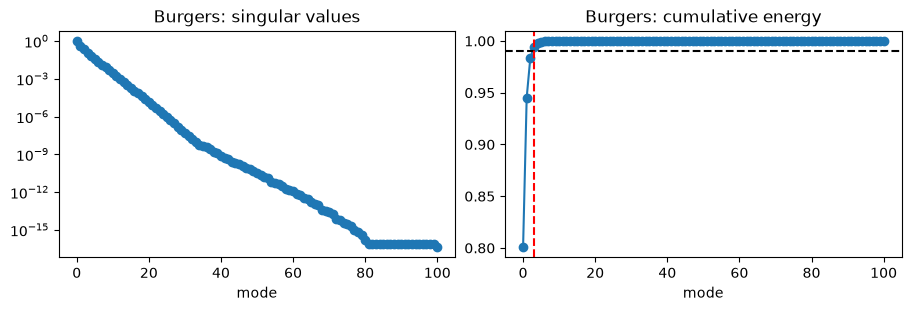

In [2]:
burgers = data.get_burgers_data()
x_burg = burgers["x"]
t_burg = burgers["t"]
u_burg = burgers["u"]
u_dot_burg = burgers["u_dot"]
burg_basis = burgers["svd"].basis
burg_ode_series = burgers["svd"].time_series


plot_burgers_data_and_derivative(x_burg, t_burg, u_burg, u_dot_burg)
plot_svd_energy(burgers["svd"], "Burgers")
print(f"Burgers 99% energy rank: {burgers['svd'].rank_99}")
print(f"Burgers number of SVD modes {burg_basis.shape[-1]}")

### Compressible, Isothermal Flow

A more challenging problem from fluid dynamics, on a 2D grid.
Advection and diffusion of a 2D velocity field, with variable density.
$$u_t = -u u_x - v u_y - p_x + \nu (u_{xx} + u_{yy})$$
$$v_t = -u v_x - v v_y - p_y + \nu (v_{xx} + v_{yy})$$
$$\rho_t = -u \rho_x - v \rho_y - \rho (u_x + v_y)$$

Compressible number of SVD modes 2
Compressible 99% energy rank: 2


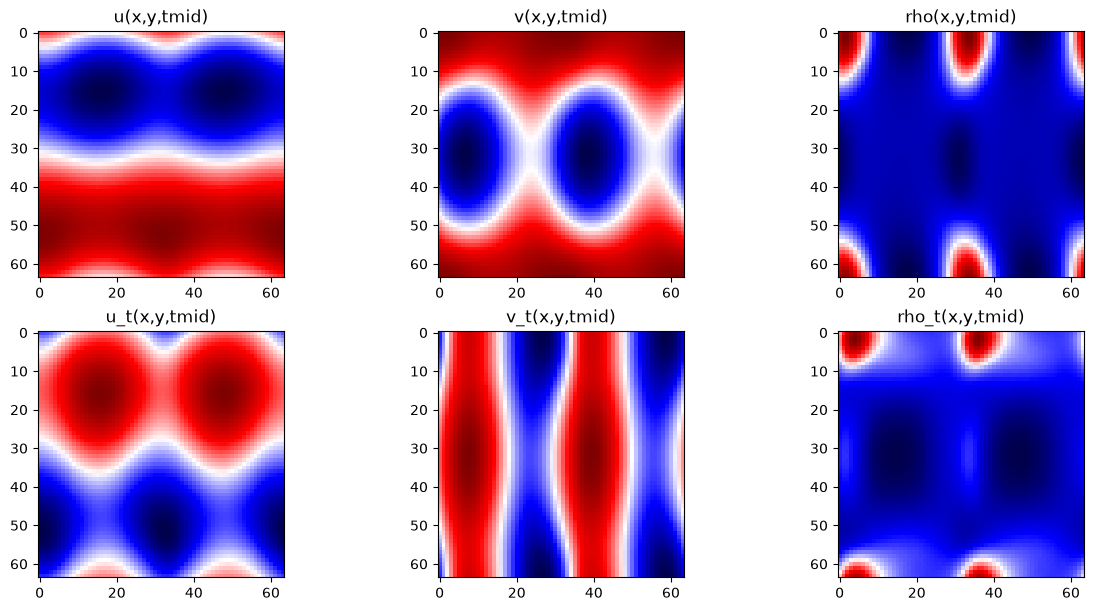

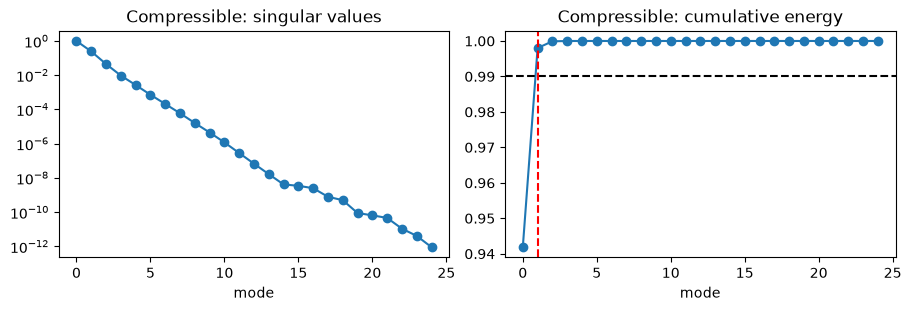

In [3]:
nx = 64
nt = 25
compressible = data.get_compressible_data(nx, nt)
x_fluid = np.stack(
    np.meshgrid(compressible["x"], compressible["y"], indexing="ij"), axis=-1
)
t_fluid = compressible["t"]
u_fluid = compressible["u"]
u_dot_fluid = compressible["u_dot"]
fluid_basis = compressible["svd"].basis
fluid_ode_series = compressible["svd"].time_series
print(f"Compressible number of SVD modes {fluid_basis.shape[-1]}")

plot_compressible_data_and_derivative(t_fluid, u_fluid, u_dot_fluid)
plot_svd_energy(compressible["svd"], "Compressible")
print(f"Compressible 99% energy rank: {compressible['svd'].rank_99}")

## Building and fitting the models

### PDEFind

PDEFIND is implemented merely as a SINDy model with a `PDELibrary`.
This may change in the future, as it requires passing the spatial grid along
with the data-independent initialization arguments.  As a consequence, it
will not work for multiple trajectories on different grids.

`PDELibrary` calls pysindy's differentiation methods to compute spatial derivatives.
A consequence of this is that the differentiation/smoothing is inherently 1-D.
By default, it computes all derivatives up to the specified order,
but this can be customized by passing `multiindices`.

In [4]:
pde_lib_burg = ps.PDELibrary(derivative_order=2, spatial_grid=x_burg)
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=False)
bias_lib = ps.PolynomialLibrary(degree=0, include_bias=True)
burg_lib = bias_lib + poly_lib + pde_lib_burg + poly_lib * pde_lib_burg
reg_wt = ps.SR3.calculate_l0_weight(0.1, 1)
opt_burg = ps.SR3(reg_weight_lam=reg_wt, regularizer="l0", max_iter=max_iter)
pdefind_burg = ps.SINDy(feature_library=burg_lib, optimizer=opt_burg)

pdefind_burg.fit(u_burg, t=t_burg, feature_names=["u"])
print("PDE-FIND Burgers model:")
pdefind_burg.print()

pde_lib_fluid = ps.PDELibrary(derivative_order=2, spatial_grid=x_fluid)
inv_lib = ps.CustomLibrary([lambda x: 1 / x], [lambda x: f"{x}" + "**-1"])
bias_lib = ps.PolynomialLibrary(degree=0, include_bias=True)
reg_wt = ps.SR3.calculate_l0_weight(0.1, 1)
opt_fluid = ps.SR3(reg_weight_lam=reg_wt, regularizer="l0", max_iter=max_iter)
fluid_lib = bias_lib + inv_lib + pde_lib_fluid + inv_lib * pde_lib_fluid
pdefind_fluid = ps.SINDy(feature_library=fluid_lib, optimizer=opt_fluid)

# Add some noise to improve condition number
rng = np.random.default_rng(0)
u_fluid += rng.normal(scale=1e-8, size=u_fluid.shape)
pdefind_fluid.fit(u_fluid, t=t_fluid, feature_names=["u", "v", "p"])
print("\nPDE-FIND Compressible model:")
pdefind_fluid.print()

PDE-FIND Burgers model:
(u)' =  0.100 u_11 + -1.002 u u_1

PDE-FIND Compressible model:
(u)' = -0.207 1 +  1.460 u_2 +  1.218 v_2 + -0.118 p_2 + -1.125 u_22 +  0.201 v_22 +  0.204 u_1 + -0.903 v_1 +  0.402 p_1 +  2.272 u_12 +  0.562 v_12 + -0.134 p_12 + -0.327 u_11 + -0.907 v_11 +  0.159 p_11 + -0.210 p**-1 u_2 + -1.098 p**-1 v_2 + -0.179 p**-1 p_2 +  2.085 p**-1 u_22 + -0.933 p**-1 v_1 + -1.381 p**-1 p_1 + -1.957 p**-1 u_12 + -0.430 p**-1 v_12 +  0.611 p**-1 u_11 +  0.892 p**-1 v_11 + -0.144 p**-1 p_11
(v)' = -0.205 p**-1 + -4.870 u_2 +  0.402 v_2 +  0.766 p_2 + -0.487 u_22 + -0.834 v_22 +  0.492 u_1 +  1.861 v_1 + -0.132 p_1 +  2.011 u_12 +  0.130 v_12 +  0.618 u_11 + -0.801 v_11 +  0.181 p_11 +  4.102 p**-1 u_2 + -0.566 p**-1 v_2 + -1.735 p**-1 p_2 +  0.656 p**-1 u_22 +  1.693 p**-1 v_22 + -1.477 p**-1 v_1 + -0.110 p**-1 p_1 + -1.605 p**-1 u_12 + -0.159 p**-1 v_12 + -0.492 p**-1 u_11 +  1.316 p**-1 v_11 + -0.265 p**-1 p_11
(p)' = -0.512 1 +  0.353 p**-1 +  0.910 u_2 + -0.153 v_2 + -

### Weak SINDy

Weak SINDy replaces pointwise derivative matching with integral penalties
over randomly sampled spatiotemporal subdomains.
This weak formulation suppresses high-frequency noise and avoids
explicitly computing unstable high-order derivatives at each grid point.

WeakSINDy can also work with ODEs - in such a case, the only change required is to
not include a PDELibrary.
WeakSINDy's API is very similar to regular `SINDy`, treating an ODE's time points
as merely a lower-dimensional spatiotemporal grid.  The shape of the spatiotemporal
field should reflect the shape of the data.

In [5]:
if __name__ == "testing":
    max_subdomains = 10
else:
    max_subdomains = 1000

st_burg = np.stack(np.meshgrid(x_burg, t_burg, indexing="ij"), axis=-1)
opt_burg2 = copy.copy(opt_burg)
weak_burg = ps.WeakSINDy(
    feature_library=burg_lib, optimizer=opt_burg2, n_subdomains=min(300, max_subdomains)
)
weak_burg.fit(u_burg, st_grids=st_burg, feature_names=["u"])
print("WeakSINDy Burgers model:")
weak_burg.print()

st_fluid = np.stack(
    np.meshgrid(compressible["x"], compressible["y"], compressible["t"], indexing="ij"),
    axis=-1,
)
opt_fluid2 = copy.copy(opt_fluid)
weak_fluid = ps.WeakSINDy(
    feature_library=fluid_lib,
    optimizer=opt_fluid2,
    n_subdomains=min(1000, max_subdomains),
)
weak_fluid.fit(u_fluid, st_grids=st_fluid, feature_names=["u", "v", "p"])
print("WeakSINDy Compressible model:")
weak_fluid.print()

WeakSINDy Burgers model:
(u)' = -1.034 u_1 u
WeakSINDy Compressible model:
(u)' =  1.855 u_2 +  1.419 v_2 + -0.205 p_2 + -1.463 u_22 +  0.228 v_22 +  0.166 p_22 + -0.245 u_1 + -1.527 v_1 +  0.667 p_1 +  2.208 u_12 +  0.730 v_12 + -0.159 p_12 + -0.590 u_11 + -0.340 v_11 +  0.186 p_11 + -0.630 u_2 p**-1 + -1.435 v_2 p**-1 +  2.566 u_22 p**-1 + -0.163 p_22 p**-1 +  0.295 u_1 p**-1 + -0.272 v_1 u**-1 + -0.259 v_1 p**-1 +  0.160 p_1 u**-1 + -1.654 p_1 p**-1 +  0.110 u_12 u**-1 + -2.179 u_12 p**-1 + -0.254 v_12 u**-1 + -0.622 v_12 p**-1 +  0.916 u_11 p**-1 +  0.493 v_11 p**-1 + -0.177 p_11 p**-1
(v)' = -0.134 1 + -0.104 p**-1 + -6.086 u_2 +  1.193 v_2 +  0.854 p_2 + -0.980 u_22 + -0.870 v_22 +  0.588 u_1 +  1.485 v_1 +  0.399 p_1 +  3.928 u_12 + -0.945 v_12 + -0.191 p_12 +  0.625 u_11 + -1.008 v_11 +  0.206 p_11 +  4.996 u_2 p**-1 + -0.963 v_2 p**-1 + -1.721 p_2 p**-1 +  0.872 u_22 p**-1 +  1.677 v_22 p**-1 + -0.782 v_1 p**-1 + -0.664 p_1 p**-1 + -3.421 u_12 p**-1 + -0.209 v_12 u**-1 +  0.87

/data/Developer/GitHub/Organizations/dynamicslab/pysindy/pysindy/optimizers/sr3.py:374: ConvergenceWarning: SR3 did not converge after 1000 iterations.
  warnings.warn(


### Regular SINDy on reduced order model, using Trapping

`TrappingSR3` is a constrained SR3 variant for quadratic reduced-order models.
It allows effective nonlinearities but encourages globally/locally-bounded
dynamics.  This is useful to allow stable long-time simulations, both for ODEs
and reduced-order models of PDEs.

Its implementation leaves a few things to be desired.  Firstly, it does not work
for `DiscreteSINDy`.  Secondly, the associated feature library must be quadratic
(`PolynomialLibrary` with degree 2).
Thirdly, by inheriting from `ConstrainedSR3`, it requires certain data-dependent
variables and knowledge of the feature library to be passed at initialization.
These idiosyncratic parameters are given a leading underscore.

In [7]:
b_rank = min(3, burgers["svd"].rank_99)

poly_lib = ps.PolynomialLibrary(degree=2, include_bias=True)
trap_opt_burg = ps.TrappingSR3(
    _n_tgts=b_rank,
    _include_bias=True,
    beta=1e-2,
    max_iter=max_iter,
    eta=1e-2,
    reg_weight_lam=1e-1,
    regularizer="l2",
    verbose=True,
)
trap_burg = ps.SINDy(feature_library=poly_lib, optimizer=trap_opt_burg)

burg_modes = burg_basis[:, :b_rank]
burg_y = burg_ode_series[:, :b_rank]
trap_burg.fit(burg_y, t=t_burg)
print("Trapping ROM Burgers model:")
trap_burg.print()


c_rank = min(5, compressible["svd"].rank_99)
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=True)
trap_opt_fluid = ps.TrappingSR3(
    _n_tgts=c_rank,
    _include_bias=True,
    beta=1e-2,
    max_iter=max_iter,
    eta=1e-2,
    reg_weight_lam=1e-1,
    regularizer="l2",
    verbose=True,
)
trap_fluid = ps.SINDy(feature_library=poly_lib, optimizer=trap_opt_fluid)

fluid_modes = fluid_basis[:, :c_rank]
fluid_y = fluid_ode_series[:, :c_rank]
trap_fluid.fit(fluid_y, t=t_fluid)
print("\nTrapping ROM Compressible model:")
trap_fluid.print()

 Iter ... |y-Xw|^2 ... |Pw-A|^2/eta ... |w|_1 ... |Qijk|/a ... |Qijk+...|/b ...   Total:


/data/Developer/GitHub/Organizations/dynamicslab/pysindy/pysindy/optimizers/trapping_sr3.py:316: UserWarning: alpha was not set, so defaulting to alpha = 1e20 which is solarge that the ||Qijk|| term in the optimization will be essentially ignored.
  warnings.warn(


GurobiError: Unknown parameter 'max_iter'

## Evaluating the models

PDEs can mostly be evaluated the same ways as any SINDy model, as described in the
`model_evaluation tutorial <./tutorial_2/example.ipynp>`_ .

### Coefficients

Coefficient metrics require knowing the true system.  Thus, we only compute them
for PDEFIND and WeakSINDy, not Trapping SINDy on the reduced order model.

#### Burgers equation

In [ ]:
b_true = burgers_true_coefficients(["u"])
b_true, burg_pdefind_coeff = sindy_exp._utils.unionize_coeff_dicts(pdefind_burg, b_true)
b_true, burg_weak_coeff = sindy_exp._utils.unionize_coeff_dicts(weak_burg, b_true)
burg_pdefind_mae = sindy_exp.coeff_metrics(burg_pdefind_coeff, b_true)["coeff_mae"]
burg_weak_mae = sindy_exp.coeff_metrics(burg_weak_coeff, b_true)["coeff_mae"]
print("Burgers PDE-FIND coefficient MAE:", burg_pdefind_mae)
print("Burgers Weak-SINDy coefficient MAE:", burg_weak_mae)
sindy_exp.compare_coefficient_plots_from_dicts(
    burg_pdefind_coeff, b_true, input_features=["u"]
)
sindy_exp.compare_coefficient_plots_from_dicts(
    burg_weak_coeff, b_true, input_features=["u"]
)

#### Compressible isothermal flow

In [ ]:
c_true = compressible_true_coefficients(["u", "v", "p"], 1, 1)
c_true, fluid_pdefind_coeff = sindy_exp._utils.unionize_coeff_dicts(
    pdefind_fluid, c_true
)
c_true, fluid_weak_coeff = sindy_exp._utils.unionize_coeff_dicts(weak_fluid, c_true)
fluid_pdefind_mae = sindy_exp.coeff_metrics(fluid_pdefind_coeff, c_true)["coeff_mae"]
fluid_weak_mae = sindy_exp.coeff_metrics(fluid_weak_coeff, c_true)["coeff_mae"]
print("Compressible PDE-FIND coefficient MAE:", fluid_pdefind_mae)
print("Compressible Weak-SINDy coefficient MAE:", fluid_weak_mae)
sindy_exp.compare_coefficient_plots_from_dicts(
    fluid_pdefind_coeff, c_true, input_features=["u"]
)
sindy_exp.compare_coefficient_plots_from_dicts(
    fluid_weak_coeff, c_true, input_features=["u"]
)

### Predictions

#### Burgers equation

In [ ]:


mid = len(burgers["t"]) // 2
pdefind_b_dot = pdefind_burg.predict(u_burg)
weak_b_dot = weak_burg.predict(u_burg)
trap_b_dot = (burg_modes @ trap_burg.predict(burg_y).T)[..., np.newaxis]
plot_field_prediction(
    u_dot_burg,
    {
        "PDE-FIND": pdefind_b_dot,
        "Weak-SINDy": weak_b_dot,
        "Trapping": trap_b_dot,
    },
    "Burgers u_t prediction",
)

#### Compressible isothermal flow

In [ ]:
mid = len(compressible["t"]) // 2
pdefind_c_dot = pdefind_fluid.predict(compressible["u"])
weak_c_dot = weak_fluid.predict(compressible["u"])
trap_c_dot = fluid_modes @ trap_fluid.predict(fluid_y).T
trap_c_dot = np.transpose(np.reshape(trap_c_dot, (nx, nx, 3, nt)), (0, 1, 3, 2))
plot_field_prediction(
    compressible["u_dot"][:, :, mid, 0],
    {
        "PDE-FIND": pdefind_c_dot[:, :, mid, 0],
        "Weak-SINDy": weak_c_dot[:, :, mid, 0],
        "Trapping": trap_c_dot[:, :, mid, 0],
    },
    "Compressible u_t prediction at t_mid",
)

### Simulation

Generic PDE simulation is tricky, so `SINDy.simulate()` only works for ODEs.
Thus, here we only simulate the Trapping reduced order ODE.

There are more specific ways to evaluate Trapping.  For more thorough evaluation
metrics, see the trapping research notebooks.

In [ ]:
b_true_a = burg_y
c_true_a = fluid_y
b_sim_a = trap_burg.simulate(b_true_a[0], burgers["t"])
c_sim_a = trap_fluid.simulate(c_true_a[0], compressible["t"])
print(
    f"Burgers ROM excess information loss: {excess_information_loss(b_true_a, b_sim_a):.3f}"
)
print(
    f"Compressible ROM excess information loss: {excess_information_loss(c_true_a, c_sim_a):.3f}"
)
print_trapping_diagnostics(trap_burg, "Burgers")
print_trapping_diagnostics(trap_fluid, "Compressible")
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(b_true_a[:, 0], alpha=0.6, label="true")
plt.plot(b_sim_a[:, 0], alpha=0.6, label="simulated")
plt.xlabel("time")
plt.title("Burgers ROM phase (first mode)")
plt.subplot(1, 2, 2)
plt.plot(c_true_a[:, 0], alpha=0.6, label="true")
plt.plot(c_sim_a[:, 0], alpha=0.6, label="simulated")
plt.xlabel("time")
plt.legend()
plt.title("Compressible ROM phase (first mode)")

### PDE simulation with RK4

`SINDy.simulate()` now supports PDE models when paired with a per-step
integrator that preserves spatial structure, such as
`pysindy.integrator.RK4Integrator` (pass `integrator="rk4"`).

The right-hand side is built by inserting a singleton sample axis before
the coordinate axis of the state, so the same `predict` path works for
both ODEs (`x0` shape `(n_features,)`) and PDEs
(`x0` shape `(*spatial, n_features)`).

Here we simulate the PDE-FIND Burgers model forward in time from the
initial spatial field `u(x, t=0)` and compare against the true data.

In [ ]:
# Simulate the PDE-FIND Burgers model forward in time using RK4.
# x0 is the spatial field at t=0: shape (n_x, n_features).
u0_burg = u_burg[:, 0, :]  # (n_x, 1)
u_sim_burg = pdefind_burg.simulate(u0_burg, t_burg, integrator="rk4")
# The integrator returns (n_t, n_x, n_features); transpose to match
# the original data convention (n_x, n_t, n_features).
u_sim_burg = np.transpose(u_sim_burg, (1, 0, 2))
print(f"PDE-FIND Burgers simulation shape: {u_sim_burg.shape}")
print(f"True Burgers data shape:           {u_burg.shape}")

# Compare the simulated field against the true field at the final time.
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(x_burg, u_burg[:, -1, 0], label="true")
plt.plot(x_burg, u_sim_burg[:, -1, 0], label="RK4 sim", linestyle="--")
plt.xlabel("x")
plt.title("Burgers u(x, t_final)")
plt.legend()

plt.subplot(1, 2, 2)
# Spatiotemporal error
err = np.abs(u_burg[..., 0] - u_sim_burg[..., 0])
plt.pcolormesh(t_burg, x_burg, err, shading="auto")
plt.colorbar(label="|u_true - u_sim|")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Burgers RK4 simulation error")
plt.tight_layout()

#### 2D PDE simulation

The same approach works for 2D spatial fields. The compressible isothermal
flow data has shape `(nx, nx, nt, 3)` — two spatial axes, time, and three
state coordinates `(u, v, p)`. We simulate the PDE-FIND model forward from
the initial 2D field `u(:, :, t=0, :)` of shape `(nx, nx, 3)`.

In [ ]:
# Simulate the PDE-FIND compressible flow model forward in time using RK4.
# x0 is the 2D spatial field at t=0: shape (nx, nx, 3).
u0_fluid = u_fluid[:, :, 0, :]  # (nx, nx, 3)
u_sim_fluid = pdefind_fluid.simulate(u0_fluid, t_fluid, integrator="rk4")
# The integrator returns (n_t, nx, nx, n_features); transpose to match
# the original data convention (nx, nx, n_t, n_features).
u_sim_fluid = np.transpose(u_sim_fluid, (1, 2, 0, 3))
print(f"PDE-FIND Compressible simulation shape: {u_sim_fluid.shape}")
print(f"True Compressible data shape:           {u_fluid.shape}")

# Compare the simulated and true u-field at the final time.
plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.imshow(u_fluid[:, :, -1, 0], cmap="seismic")
plt.title("True u(x,y, t_final)")
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(u_sim_fluid[:, :, -1, 0], cmap="seismic")
plt.title("RK4 sim u(x,y, t_final)")
plt.colorbar()
plt.subplot(1, 3, 3)
plt.imshow(
    np.abs(u_fluid[:, :, -1, 0] - u_sim_fluid[:, :, -1, 0]), cmap="viridis"
)
plt.title("|true - sim|")
plt.colorbar()
plt.tight_layout()

The same RK4-based simulation works for `WeakSINDy` PDE models, which
previously raised a `TypeError` for any PDE (`grid_ndim_ > 1`). The
`WeakSINDy.simulate` now delegates to `SINDy.simulate`, so passing
`integrator="rk4"` enables weak-form PDE simulation.

In [ ]:
# Simulate the WeakSINDy Burgers PDE model with RK4.
u_sim_weak_burg = weak_burg.simulate(u0_burg, t_burg, integrator="rk4")
# The integrator returns (n_t, n_x, n_features); transpose to match
# the original data convention (n_x, n_t, n_features).
u_sim_weak_burg = np.transpose(u_sim_weak_burg, (1, 0, 2))
print(f"WeakSINDy Burgers simulation shape: {u_sim_weak_burg.shape}")

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(x_burg, u_burg[:, -1, 0], label="true")
plt.plot(x_burg, u_sim_weak_burg[:, -1, 0], label="RK4 weak sim", linestyle="--")
plt.xlabel("x")
plt.title("WeakSINDy Burgers u(x, t_final)")
plt.legend()

plt.subplot(1, 2, 2)
err_weak = np.abs(u_burg[..., 0] - u_sim_weak_burg[..., 0])
plt.pcolormesh(t_burg, x_burg, err_weak, shading="auto")
plt.colorbar(label="|u_true - u_sim|")
plt.xlabel("t")
plt.ylabel("x")
plt.title("WeakSINDy RK4 simulation error")
plt.tight_layout()